# 准备数据

In [1]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [3]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi300")

In [4]:
# 设置任务参数
name = "300_mlp"
index_symbol: str = "000300.SSE"
start: str = "2007-01-01"
end: str = "2024-10-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [5]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

In [6]:
print(component_symbols)

['603587.SSE', '600981.SSE', '600396.SSE', '600612.SSE', '300619.SZSE', '601899.SSE', '600563.SSE', '605050.SSE', '002179.SZSE', '300393.SZSE', '301205.SZSE', '300877.SZSE', '001380.SZSE', '300377.SZSE', '002281.SZSE', '301007.SZSE', '002251.SZSE', '603228.SSE', '002613.SZSE', '002093.SZSE', '601231.SSE', '603285.SSE', '300498.SZSE', '002042.SZSE', '002021.SZSE', '300197.SZSE', '603322.SSE', '601997.SSE', '688786.SSE', '601068.SSE', '603858.SSE', '688677.SSE', '300137.SZSE', '601628.SSE', '603313.SSE', '002099.SZSE', '001319.SZSE', '603689.SSE', '600552.SSE', '000848.SZSE', '600159.SSE', '002953.SZSE', '603231.SSE', '605018.SSE', '300283.SZSE', '000401.SZSE', '301177.SZSE', '600527.SSE', '000501.SZSE', '603918.SSE', '300279.SZSE', '600428.SSE', '688626.SSE', '002612.SZSE', '300935.SZSE', '000551.SZSE', '601989.SSE', '000629.SZSE', '603266.SSE', '000597.SZSE', '300249.SZSE', '300124.SZSE', '600203.SSE', '603043.SSE', '002501.SZSE', '300850.SZSE', '301222.SZSE', '688046.SSE', '605158.SSE

# 特征计算

In [7]:
# 加载模块
from datetime import datetime
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_robust_zscore_norm,
    process_fill_na,
    process_cs_rank_norm,
    to_datetime
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [8]:
# 加载成分股数据
component_symbols=component_symbols[:500]
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

2025-10-29 19:12:28 File lab/csi300/daily/603205.SSE.parquet does not exist
2025-10-29 19:12:28 File lab/csi300/daily/603406.SSE.parquet does not exist
2025-10-29 19:12:29 File lab/csi300/daily/001400.SZSE.parquet does not exist
2025-10-29 19:12:29 File lab/csi300/daily/001356.SZSE.parquet does not exist


In [9]:
# 设置数据时间段
train_period: tuple[str, str] = ("2007-01-01", "2020-12-31")
valid_period: tuple[str, str] = ("2021-01-01", "2021-12-31")
test_period: tuple[str, str] = ("2022-01-01", "2024-10-31")

In [10]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period=train_period,
    valid_period=valid_period,
    test_period=test_period,
)

In [11]:
# 添加数据预处理器
fit_start_time: datetime = to_datetime(train_period[0])
fit_end_time: datetime = to_datetime(train_period[1])
print(f"fit_start_time: {fit_start_time}")
print(f"fit_end_time: {fit_end_time}")
dataset.add_processor("infer", partial(process_robust_zscore_norm, fit_start_time=fit_start_time, fit_end_time=fit_end_time))
dataset.add_processor("infer", partial(process_fill_na, fill_value=0, fill_label=False))

dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_rank_norm, names=["label"]))

fit_start_time: 2007-01-01 00:00:00
fit_end_time: 2020-12-31 00:00:00


In [12]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [13]:
print(filters)

defaultdict(<class 'list'>, {'603587.SSE': [(datetime.datetime(2007, 1, 1, 0, 0), datetime.datetime(2024, 10, 31, 0, 0))], '600981.SSE': [(datetime.datetime(2007, 1, 1, 0, 0), datetime.datetime(2024, 10, 31, 0, 0))], '600396.SSE': [(datetime.datetime(2007, 1, 1, 0, 0), datetime.datetime(2024, 10, 31, 0, 0))], '600612.SSE': [(datetime.datetime(2007, 1, 1, 0, 0), datetime.datetime(2024, 10, 31, 0, 0))], '300619.SZSE': [(datetime.datetime(2007, 1, 1, 0, 0), datetime.datetime(2024, 10, 31, 0, 0))], '601899.SSE': [(datetime.datetime(2007, 1, 1, 0, 0), datetime.datetime(2024, 10, 31, 0, 0))], '600563.SSE': [(datetime.datetime(2007, 1, 1, 0, 0), datetime.datetime(2024, 10, 31, 0, 0))], '605050.SSE': [(datetime.datetime(2007, 1, 1, 0, 0), datetime.datetime(2024, 10, 31, 0, 0))], '002179.SZSE': [(datetime.datetime(2007, 1, 1, 0, 0), datetime.datetime(2024, 10, 31, 0, 0))], '300393.SZSE': [(datetime.datetime(2007, 1, 1, 0, 0), datetime.datetime(2024, 10, 31, 0, 0))], '301205.SZSE': [(datetime.da

In [14]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=15)

2025-10-29 19:12:30 开始计算表达式因子特征


  1%|          | 1/159 [00:01<03:25,  1.30s/it]

Feature calculation kmid took: 0.011362791061401367 seconds | (close - open) / open
Feature calculation klen took: 0.006198406219482422 seconds | (high - low) / open


  1%|▏         | 2/159 [00:01<01:44,  1.50it/s]

Feature calculation kmid_2 took: 0.009476423263549805 seconds | (close - open) / (high - low + 1e-12)


...


0it [00:00, ?it/s]

2025-10-29 19:14:16 合并结果数据因子特征完成 | 数量: 0 | 耗时: 0.001s
2025-10-29 19:14:16 生成 raw_df（填充 NaN）| 耗时: 0.071s
2025-10-29 19:14:16 开始筛选成分股数据


2025-10-29 19:14:16 筛选成分股数据完成 | 合计合并条目: 5153 | 耗时: 0.086s


/home/lai/test_v1/vnpy/vnpy/alpha/dataset/template.py:173: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  joined = raw_df.join_asof(


2025-10-29 19:14:16 选择特征列并排序完成 | 列数: 161 | 耗时: 0.097s
2025-10-29 19:14:18 infer 处理器[1] partial 完成 | 耗时: 2.169s
2025-10-29 19:14:18 infer 处理器[2] partial 完成 | 耗时: 0.078s
2025-10-29 19:14:18 学习数据赋值完成（process_type=append）| 耗时: 0.000s
2025-10-29 19:14:18 learn 处理器[1] partial 完成 | 耗时: 0.003s
2025-10-29 19:14:18 learn 处理器[2] partial 完成 | 耗时: 0.036s


In [15]:
# 特征表现分析
#dataset.show_feature_performance("ma_60")

In [16]:
dataset.df.shape

(1078239, 10)

In [17]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [18]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.mlp_model import MlpModel

In [19]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [20]:
dataset.df.shape

(1078239, 10)

In [21]:
# 创建模型对象
kwargs = {
    "input_size": 158,
    "hidden_sizes": (256,),
    "lr": 0.002,
    "optimizer": "adam",
    "n_epochs": 8000,
    "batch_size": 8192,
    "weight_decay": 0.0002,
    "seed": 42
}

model: AlphaModel = MlpModel(**kwargs)

In [22]:
from vnpy.alpha import Segment
df_train = dataset.fetch_learn(Segment.TRAIN)
print("TRAIN shape:", df_train.shape)
print(df_train.head())
print("TRAIN unique symbols:", df_train["vt_symbol"].unique()[:20])
print("TRAIN dates:", df_train["datetime"].min(), df_train["datetime"].max())

TRAIN shape: (658861, 161)
shape: (5, 161)
┌────────────┬────────────┬───────────┬───────────┬───┬──────────┬──────────┬──────────┬───────────┐
│ datetime   ┆ vt_symbol  ┆ kmid      ┆ klen      ┆ … ┆ vsumd_20 ┆ vsumd_30 ┆ vsumd_60 ┆ label     │
│ ---        ┆ ---        ┆ ---       ┆ ---       ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---       │
│ datetime[μ ┆ str        ┆ f64       ┆ f64       ┆   ┆ f64      ┆ f64      ┆ f64      ┆ f64       │
│ s]         ┆            ┆           ┆           ┆   ┆          ┆          ┆          ┆           │
╞════════════╪════════════╪═══════════╪═══════════╪═══╪══════════╪══════════╪══════════╪═══════════╡
│ 2010-01-04 ┆ 000016.SZS ┆ -0.838715 ┆ -0.412135 ┆ … ┆ 0.0      ┆ 0.0      ┆ 0.0      ┆ -1.705286 │
│ 00:00:00   ┆ E          ┆           ┆           ┆   ┆          ┆          ┆          ┆           │
│ 2010-01-04 ┆ 000048.SZS ┆ 0.245058  ┆ -0.109966 ┆ … ┆ 0.0      ┆ 0.0      ┆ 0.0      ┆ -0.148286 │
│ 00:00:00   ┆ E          ┆           ┆         

In [23]:
# 使用数据集训练模型
model.fit(dataset)

2025-10-29 19:14:32 [Step 20]: train_loss 1.234746, valid_loss 1.076700
2025-10-29 19:14:32 	验证集损失从 inf 降低到 1.076700


/home/lai/miniconda3/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:1347: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


2025-10-29 19:14:33 [Step 40]: train_loss 1.080425, valid_loss 1.024248
2025-10-29 19:14:33 	验证集损失从 1.076700 降低到 1.024248
2025-10-29 19:14:33 [Step 60]: train_loss 1.049246, valid_loss 1.013664
2025-10-29 19:14:33 	验证集损失从 1.024248 降低到 1.013664
2025-10-29 19:14:34 [Step 80]: train_loss 1.037641, valid_loss 1.010576
2025-10-29 19:14:34 	验证集损失从 1.013664 降低到 1.010576
2025-10-29 19:14:34 [Step 100]: train_loss 1.025174, valid_loss 1.008412
2025-10-29 19:14:34 	验证集损失从 1.010576 降低到 1.008412
2025-10-29 19:14:35 [Step 120]: train_loss 1.017132, valid_loss 1.004380
2025-10-29 19:14:35 	验证集损失从 1.008412 降低到 1.004380
2025-10-29 19:14:35 [Step 140]: train_loss 1.015376, valid_loss 1.003279
2025-10-29 19:14:35 	验证集损失从 1.004380 降低到 1.003279
2025-10-29 19:14:36 [Step 160]: train_loss 1.011222, valid_loss 1.001470
2025-10-29 19:14:36 	验证集损失从 1.003279 降低到 1.001470
2025-10-29 19:14:36 [Step 180]: train_loss 1.004911, valid_loss 1.000793
2025-10-29 19:14:36 	验证集损失从 1.001470 降低到 1.000793
2025-10-29 19:14:37

In [24]:
# 查看模型细节
model.detail()

2025-10-29 19:15:43 输入特征维度: 158
2025-10-29 19:15:43 隐藏层大小: (256,)
2025-10-29 19:15:43 模型总参数量: 41,473
2025-10-29 19:15:43 训练设备: cpu
2025-10-29 19:15:43 当前学习率: 0.002
2025-10-29 19:15:43 批次大小: 8192


,Importance
Feature,
rank_5,0.002428
max_20,0.001692
resi_5,0.001582
beta_5,0.001547
roc_20,0.001414
...,...
kup_2,0.000585
imxd_20,0.000550
rank_60,0.000541


In [25]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [26]:
model: AlphaModel = lab.load_model(name)

In [27]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

infer freq: None
Dropped 1.5% entries from factor data: 1.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.771023,-0.060993,-0.240256,0.095892,31880,10.091098
2,-0.502839,0.015639,-0.107494,0.045124,31452,9.955622
3,-0.476341,0.069209,-0.054881,0.041148,31686,10.029691
4,-0.454378,0.115083,-0.018395,0.040178,31421,9.945809
5,-0.438243,0.151841,0.011161,0.040549,31769,10.055963
6,-0.419264,0.186161,0.038398,0.041105,31348,9.922702
7,-0.402401,0.218095,0.065195,0.042076,31390,9.935997
8,-0.385726,0.250689,0.094111,0.043520,31717,10.039503
9,-0.354278,0.303126,0.129993,0.045378,31421,9.945809


Returns Analysis


,1D,5D,10D
Ann. alpha,0.525,0.319,0.222
beta,-0.030,-0.015,-0.015
Mean Period Wise Return Top Quantile (bps),14.182,8.343,6.027
Mean Period Wise Return Bottom Quantile (bps),-29.352,-19.819,-12.865
Mean Period Wise Spread (bps),43.534,28.293,19.006


<Figure size 640x480 with 0 Axes>

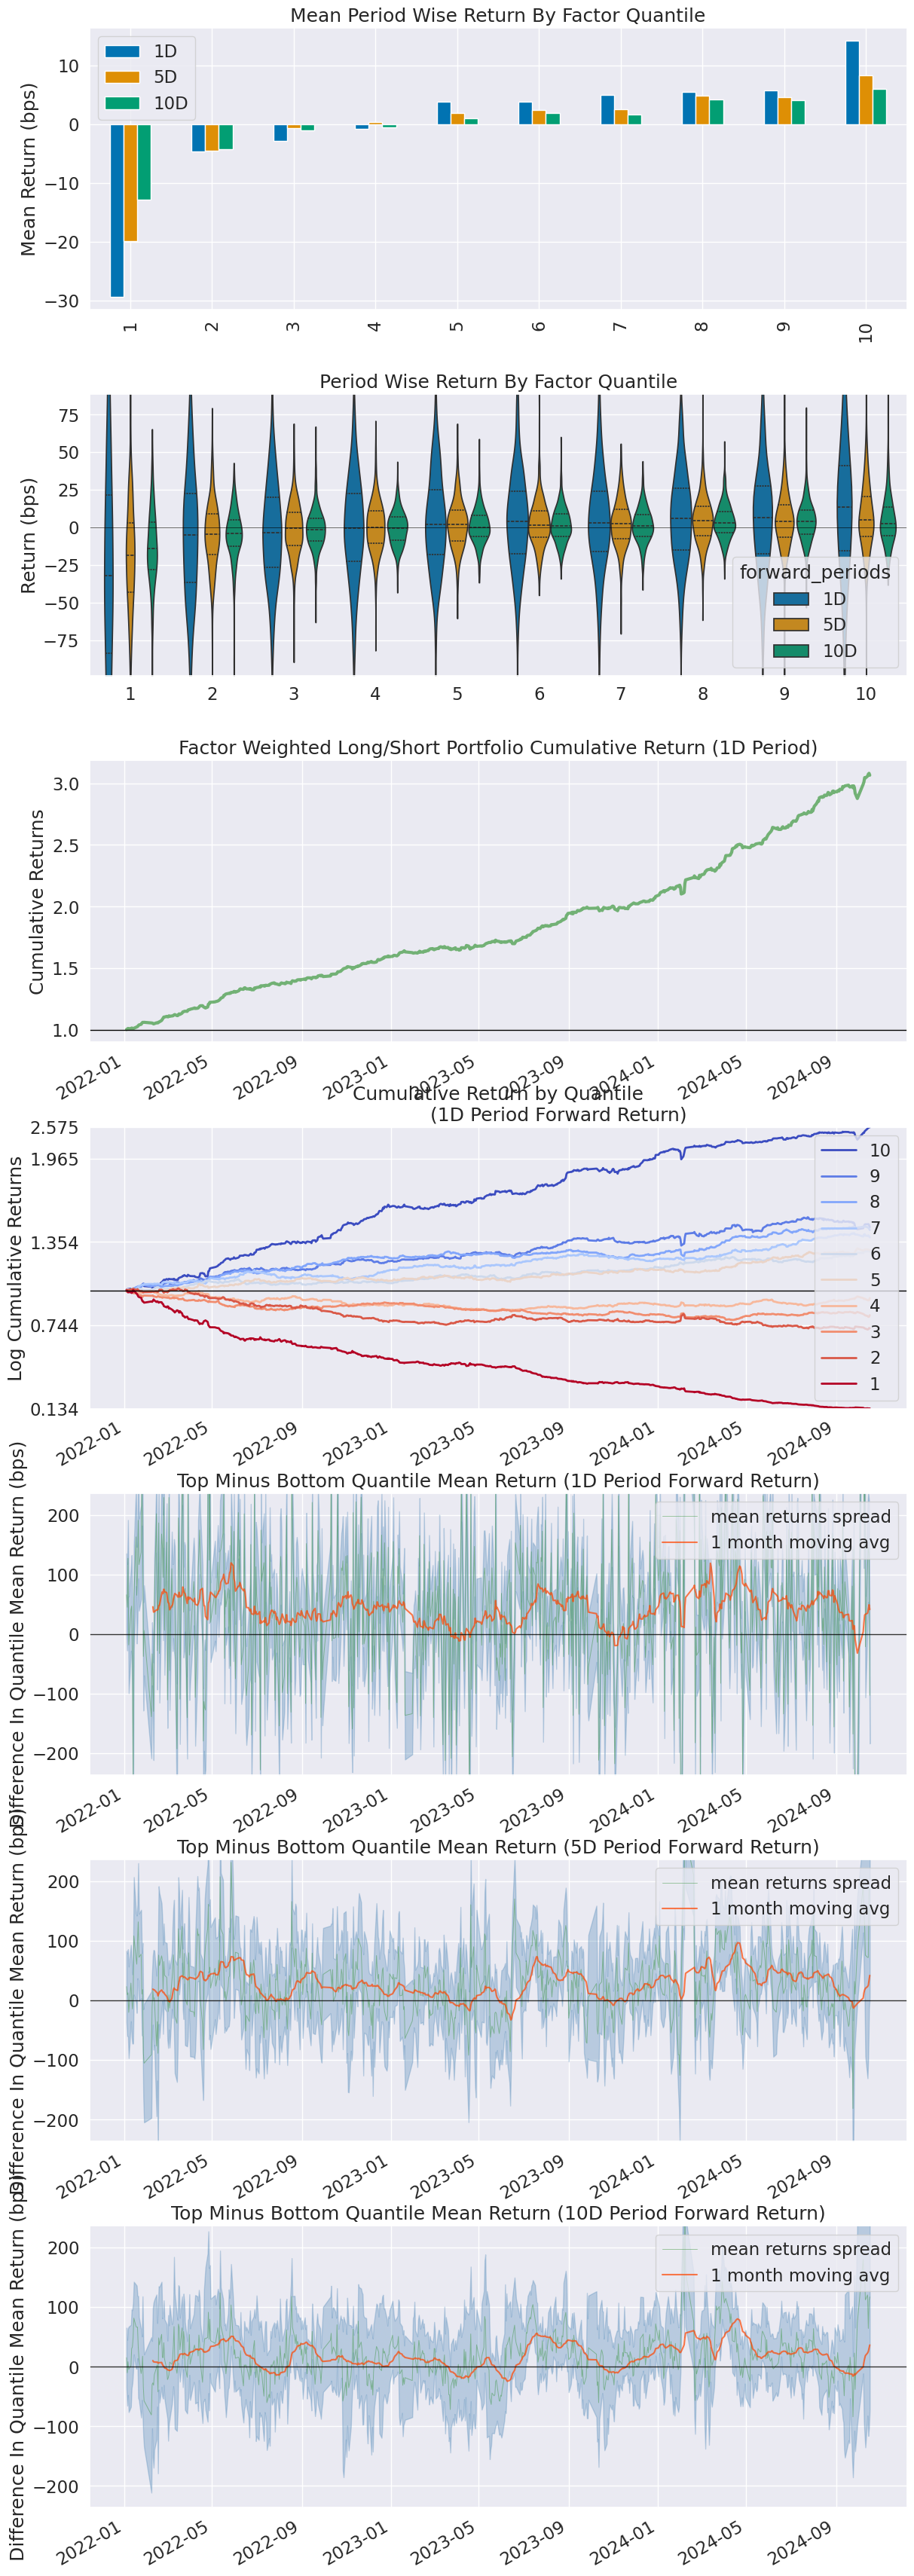

Information Analysis


,1D,5D,10D
IC Mean,0.076,0.092,0.095
IC Std.,0.109,0.106,0.105
Risk-Adjusted IC,0.697,0.864,0.897
t-stat(IC),18.069,22.407,23.266
p-value(IC),0.000,0.000,0.000
IC Skew,-0.222,0.053,0.300
IC Kurtosis,1.251,0.576,0.886


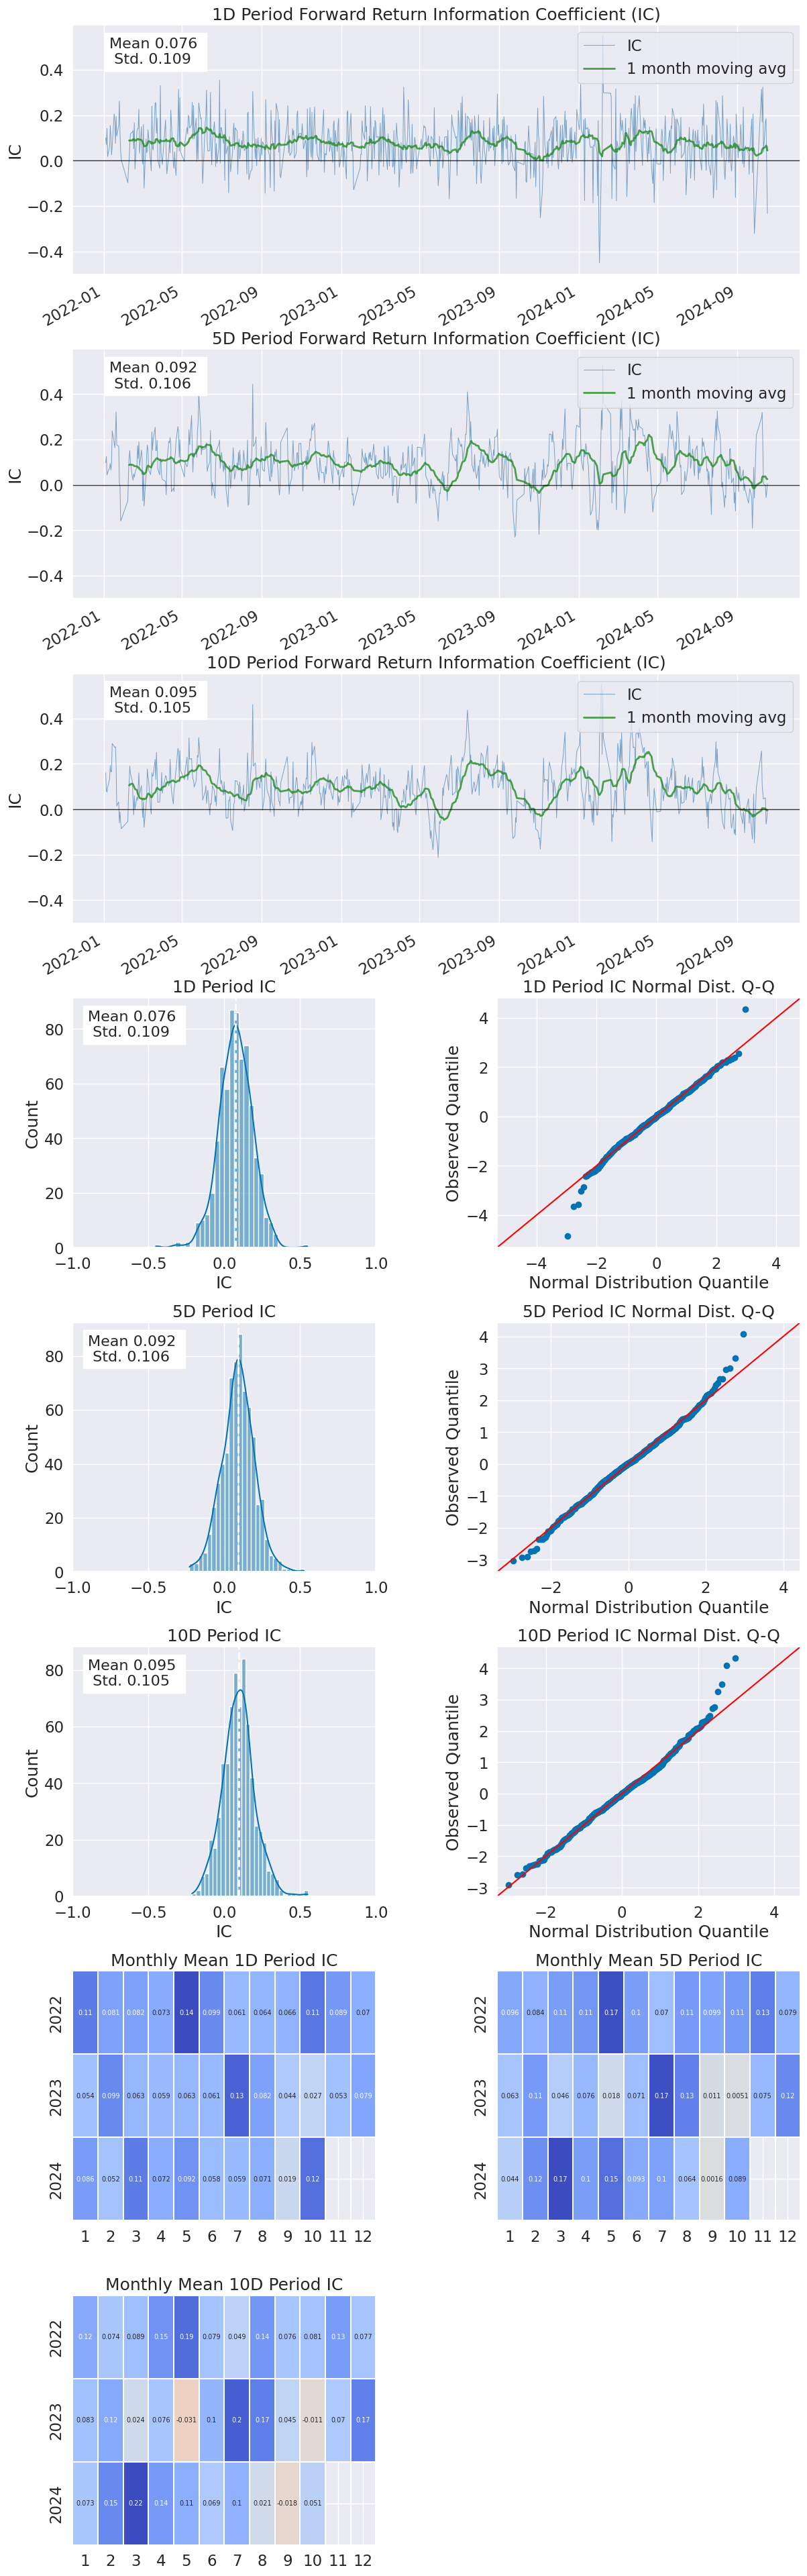

/home/lai/miniconda3/lib/python3.13/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.427,0.691,0.739
Quantile 2 Mean Turnover,0.732,0.853,0.863
Quantile 3 Mean Turnover,0.796,0.871,0.883
Quantile 4 Mean Turnover,0.821,0.882,0.889
Quantile 5 Mean Turnover,0.840,0.885,0.891
Quantile 6 Mean Turnover,0.842,0.886,0.892
Quantile 7 Mean Turnover,0.830,0.882,0.887
Quantile 8 Mean Turnover,0.807,0.873,0.882
Quantile 9 Mean Turnover,0.761,0.855,0.870
Quantile 10 Mean Turnover,0.508,0.756,0.811


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.704,0.337,0.25


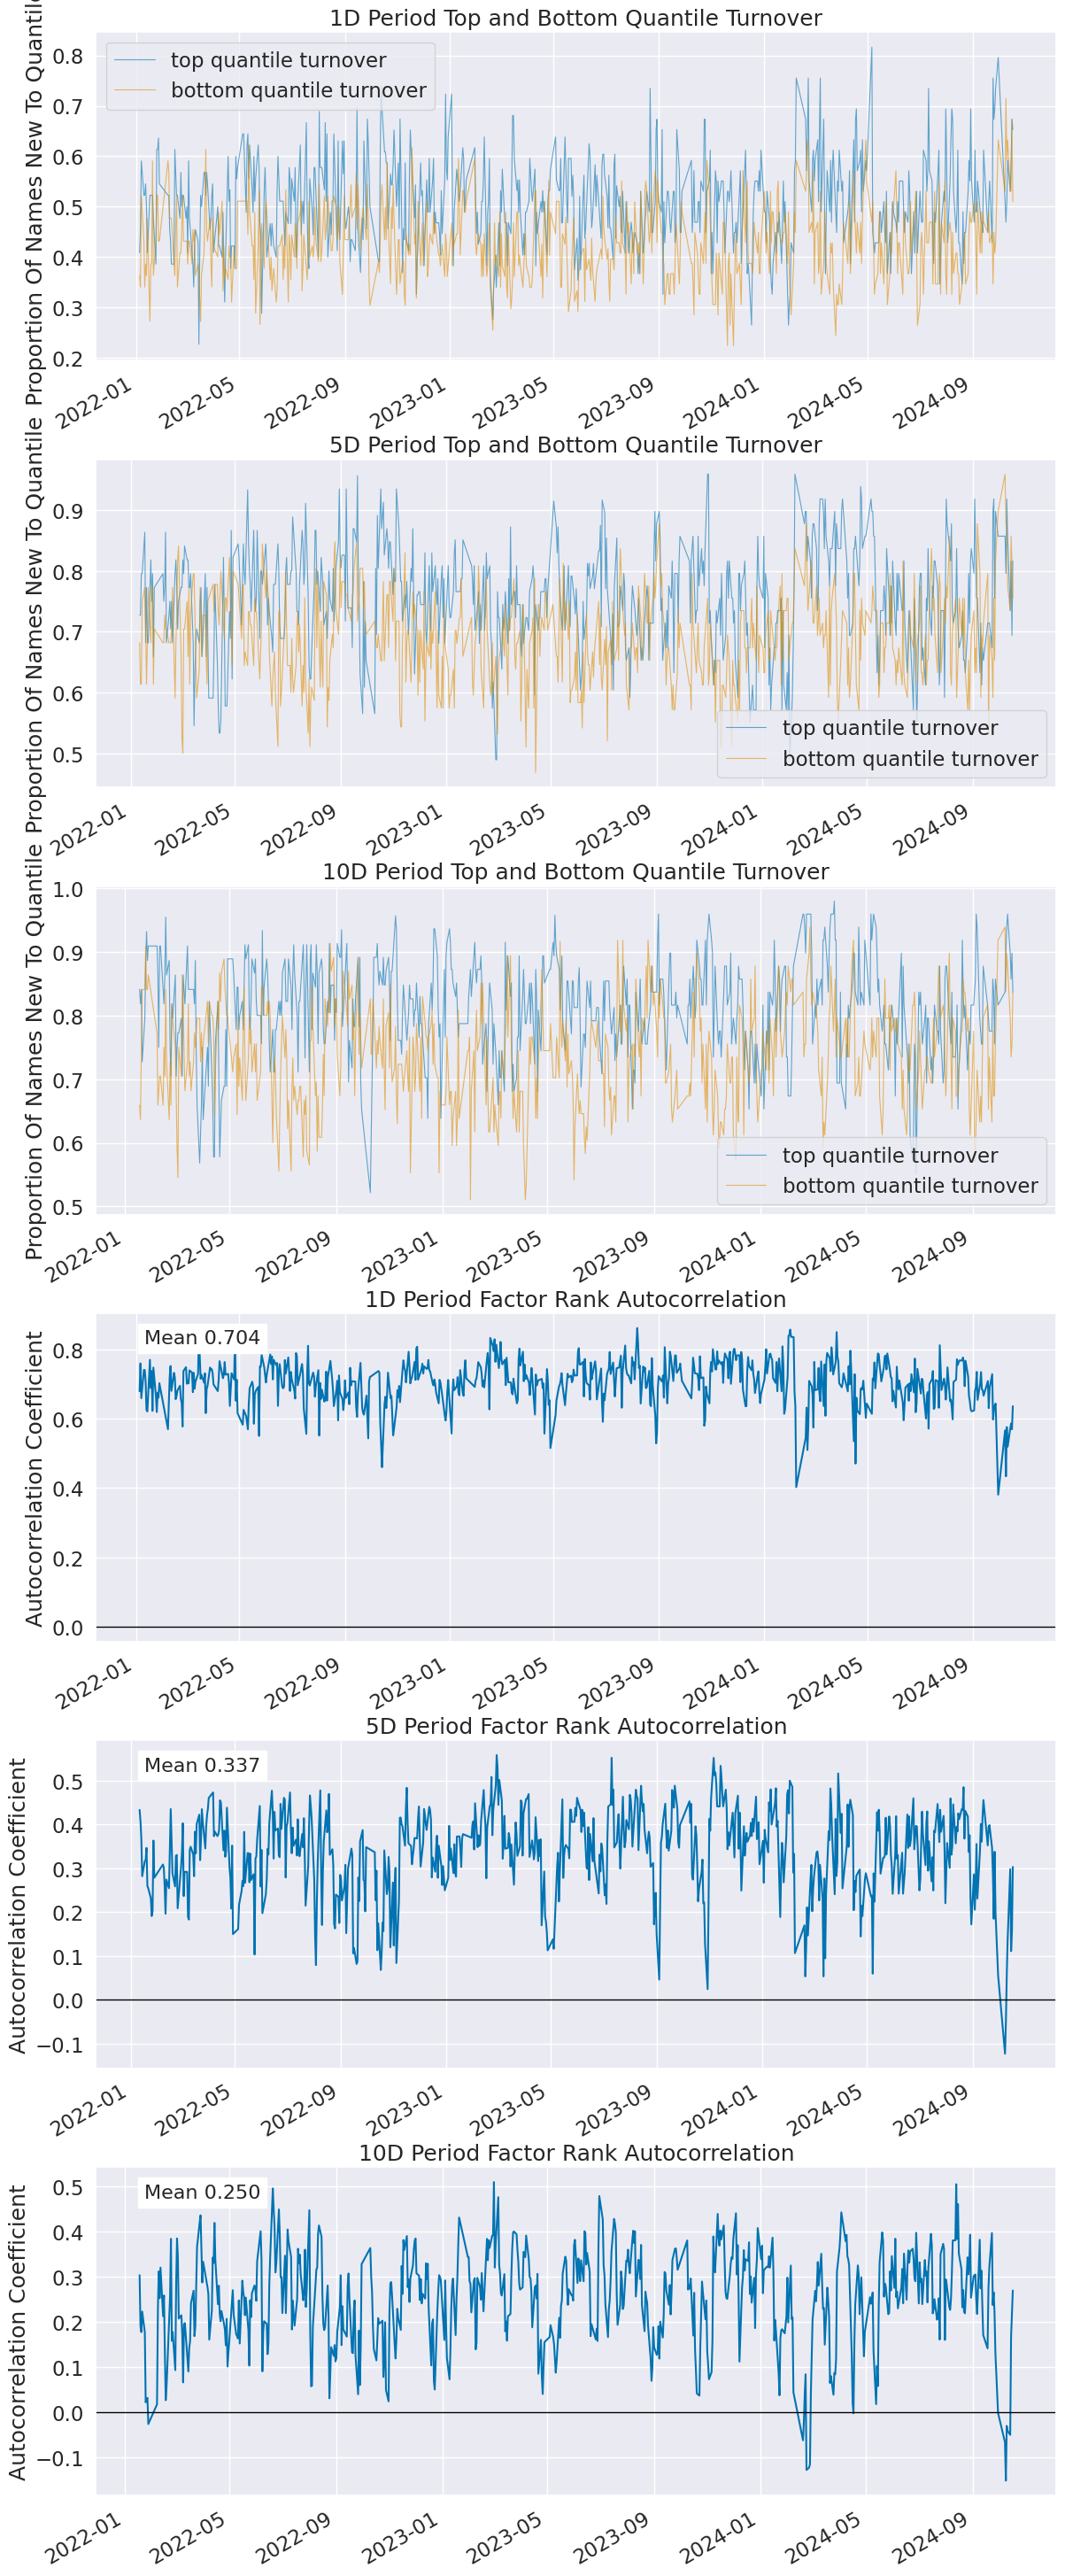

In [28]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [29]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [30]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [31]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [32]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [33]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2022, 1, 1),
    end=datetime(2024, 10, 31),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [34]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2025-10-29 19:15:50 开始加载历史数据


 61%|██████▏   | 307/500 [00:02<00:01, 174.69it/s]

2025-10-29 19:15:53 File lab/csi300/daily/603205.SSE.parquet does not exist


 71%|███████   | 353/500 [00:02<00:00, 231.27it/s]

2025-10-29 19:15:53 File lab/csi300/daily/603406.SSE.parquet does not exist


...

 99%|█████████▉| 494/500 [00:04<00:00, 107.50it/s]

2025-10-29 19:15:55 File lab/csi300/daily/001356.SZSE.parquet does not exist


100%|██████████| 500/500 [00:04<00:00, 118.36it/s]

2025-10-29 19:15:55 部分合约历史数据为空：['603205.SSE', '603406.SSE', '001400.SZSE', '001356.SZSE']
2025-10-29 19:15:55 所有历史数据加载完成，共496个合约
2025-10-29 19:15:55 策略初始化完成
2025-10-29 19:15:55 开始回放历史数据


2025-10-29 19:15:59 历史数据回放结束
2025-10-29 19:15:59 开始计算逐日盯市盈亏
2025-10-29 19:15:59 逐日盯市盈亏计算完成
2025-10-29 19:15:59 开始计算策略统计指标
2025-10-29 19:15:59 ------------------------------
2025-10-29 19:15:59 首个交易日：  2022-01-04
2025-10-29 19:15:59 最后交易日：  2024-10-31
2025-10-29 19:15:59 总交易日：  683
2025-10-29 19:15:59 盈利交易日：  363
2025-10-29 19:15:59 亏损交易日：  319
2025-10-29 19:15:59 起始资金：  100,000,000.00
2025-10-29 19:15:59 结束资金：  122,987,327.88
2025-10-29 19:15:59 总收益率：  22.99%
2025-10-29 19:15:59 年化收益：  8.08%
2025-10-29 19:15:59 最大回撤:   -34,430,622.51
2025-10-29 19:15:59 百分比最大回撤: -29.65%
2025-10-29 19:15:59 最长回撤天数:   74
2025-10-29 19:15:59 总盈亏：  22,987,327.88
2025-10-29 19:15:59 总手续费：  1,290,527.57
2025-10-29 19:15:59 总成交金额：  1,753,562,275.20
2025-10-29 19:15:59 总成交笔数：  4089
2025-10-29 19:15:59 日均盈亏：  33,656.41
2025-10-29 19:15:59 日均手续费：  1,889.50
2025-10-29 19:15:59 日均成交金额：  2,567,441.11
2025-10-29 19:15:59 日均成交笔数：  5.986822840409956
2025-10-29 19:15:59 日均收益率：  0.04%
2025-10-29 19:15:59 收益标准差：  1.54%
2

In [35]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)

2025-10-29 19:15:59 File lab/csi300/daily/000300.SSE.parquet does not exist


ShapeError: unable to add a column of length 0 to a DataFrame of height 683